#### Convolutional neural network (CNN) : Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.utils import to_categorical # to_categorical speeling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten, MaxPooling2D, Conv2D
from tensorflow.keras.optimizers import Adam # It is optimizers and A is capital

/Users/niranjan/Documents/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
train_df = pd.read_csv('fashion-mnist_train.csv')
test_df = pd.read_csv('fashion-mnist_test.csv')

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
train_df['label'].unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

In [6]:
X_train = train_df.iloc[:,1:].values
y_train = train_df.iloc[:,0].values

X_test = test_df.iloc[:,1:].values
y_test = test_df.iloc[:,0].values

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [9]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [10]:
model = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='sigmoid')
])

model.compile(optimizer= Adam(), loss = "categorical_crossentropy", metrics=["accuracy"])
model.summary()

/Users/niranjan/Documents/venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-10 11:21:01.918625: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-05-10 11:21:01.918646: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-10 11:21:01.918650: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-10 11:21:01.918784: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-10 11:21:01.918792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factor

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs = 10, # here epochs 10
    batch_size = 64,
    validation_split = 0.1
)

Epoch 1/10


2026-05-10 11:21:02.608109: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.6641 - loss: 0.9634 - val_accuracy: 0.8468 - val_loss: 0.4359
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8250 - loss: 0.4851 - val_accuracy: 0.8653 - val_loss: 0.3831
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8351 - loss: 0.4309 - val_accuracy: 0.8687 - val_loss: 0.3442
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8192 - loss: 0.4055 - val_accuracy: 0.8693 - val_loss: 0.3301
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7835 - loss: 0.3894 - val_accuracy: 0.7727 - val_loss: 0.3309
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.7190 - loss: 0.3862 - val_accuracy: 0.6915 - val_loss: 0.3171
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6447 - loss: 0.3909 - val_accuracy: 0.6330 - val_loss: 0.3460
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.6040 - loss: 0.3828 - val_accurac

In [12]:
loss, accuracy = model.evaluate(X_test,y_test_cat)
print('Loss is ', loss , ' and accuracy is ', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3909 - loss: 0.3548
Loss is  0.34437474608421326  and accuracy is  0.40049999952316284


In [13]:
y_pred = np.argmax(model.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [14]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.22      0.97      0.36      1000
           1       0.95      0.93      0.94      1000
           2       0.48      0.15      0.23      1000
           3       0.67      0.36      0.47      1000
           4       0.46      0.06      0.10      1000
           5       0.35      1.00      0.52      1000
           6       0.25      0.05      0.08      1000
           7       0.91      0.13      0.22      1000
           8       0.98      0.35      0.52      1000
           9       1.00      0.00      0.00      1000

    accuracy                           0.40     10000
   macro avg       0.63      0.40      0.34     10000
weighted avg       0.63      0.40      0.34     10000



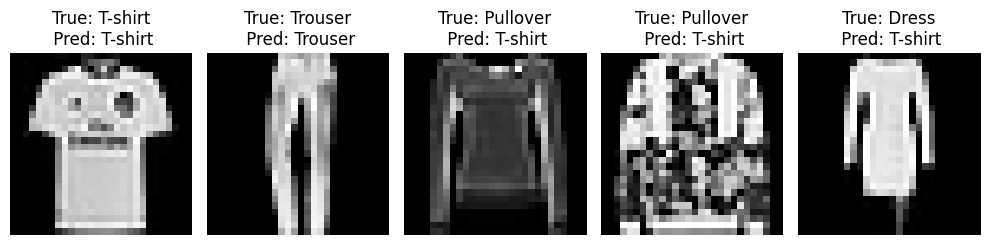

In [15]:
labels = ['T-shirt','Trouser','Pullover','Dress','Coat','Sneaker','Shirt','Sandal','Bag','Ankle boot']
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {labels[y_test[i]]}\n Pred: {labels[y_pred[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()